In [1]:
!pip install tensorflow openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
data_folder   = r"/content"
output_folder = r"/content"

os.makedirs(output_folder, exist_ok=True)

files = glob.glob(os.path.join(data_folder, "RevenueCenter_*.xlsx"))

In [4]:
# Error matrix
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

In [5]:
def create_sequences(series, window=30):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)


Processing: RevenueCenter_5
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 287ms/step - loss: 0.1231 - val_loss: 0.1685
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0238 - val_loss: 0.0781
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0169 - val_loss: 0.0147
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0113 - val_loss: 0.0171
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0097 - val_loss: 0.0137
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0093 - val_loss: 0.0243
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0117 - val_loss: 0.0248
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0074 - val_loss: 0.0255
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0090 - val_loss: 0.0412
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0078 - val_loss: 0.0306
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0085 - val_loss: 0.0198
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.

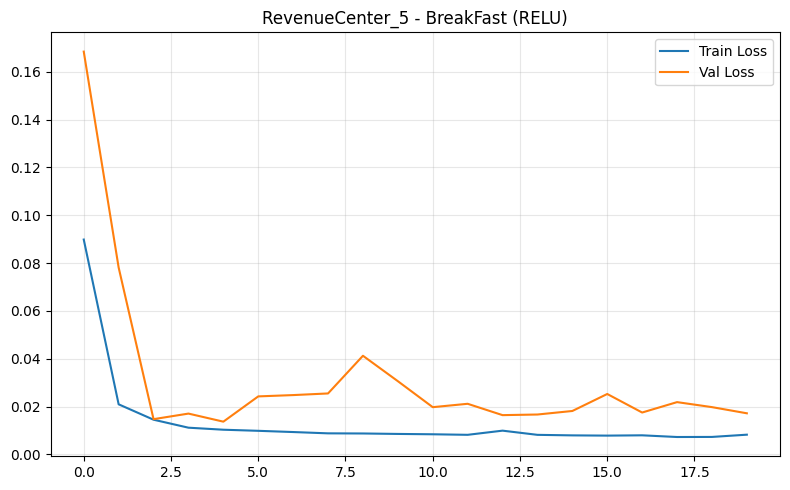

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step


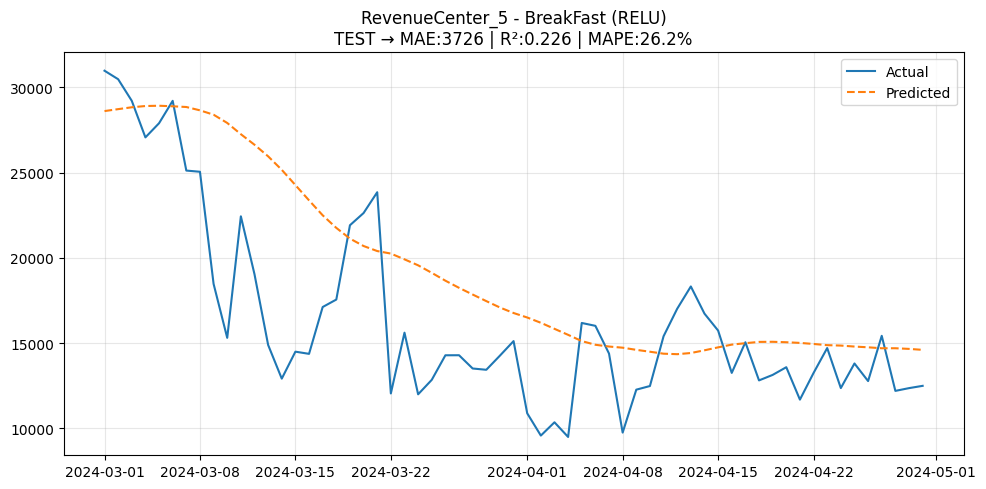

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 252ms/step - loss: 0.0214 - val_loss: 0.0161
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0104 - val_loss: 0.0202
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0142 - val_loss: 0.0170
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0137 - val_loss: 0.0168
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0174 - val_loss: 0.0184
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0143 - val_loss: 0.0180
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0169 - val_loss: 0.0166
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0150 - val_loss: 0.0175
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0194 - val_loss: 0.0172
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0178 - val_loss: 0.0168
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0135 - val_loss: 0.0167
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.

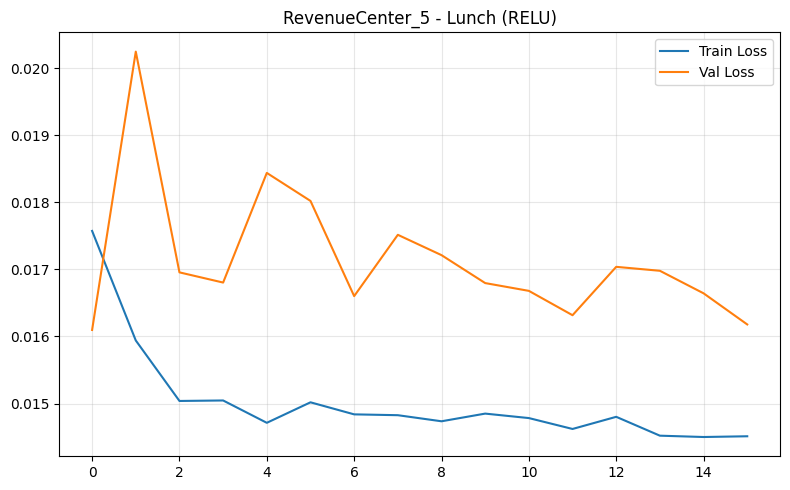

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step


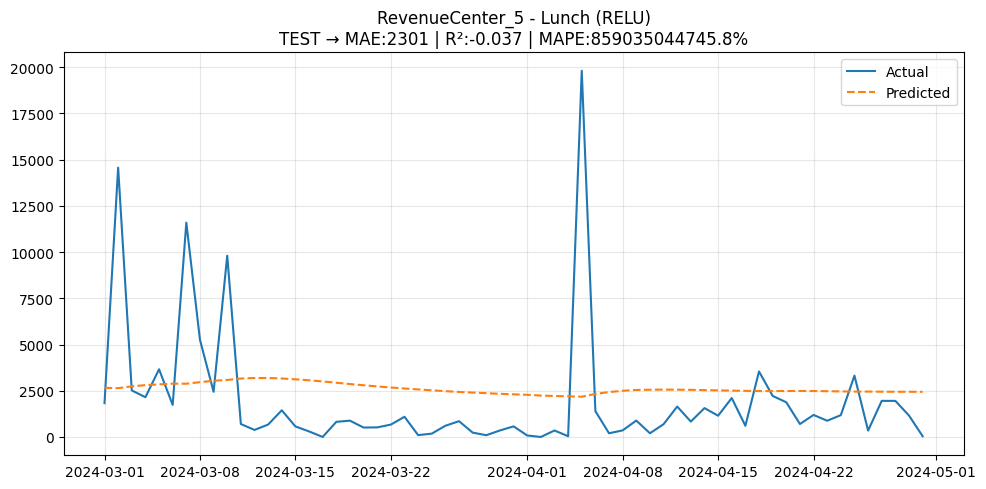

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 258ms/step - loss: 0.0328 - val_loss: 0.0517
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0257 - val_loss: 0.0598
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0203 - val_loss: 0.0534
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0223 - val_loss: 0.0564
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0208 - val_loss: 0.0540
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0188 - val_loss: 0.0551
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0244 - val_loss: 0.0554
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0203 - val_loss: 0.0550
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0188 - val_loss: 0.0596
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0196 - val_loss: 0.0566
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0238 - val_loss: 0.0597
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.

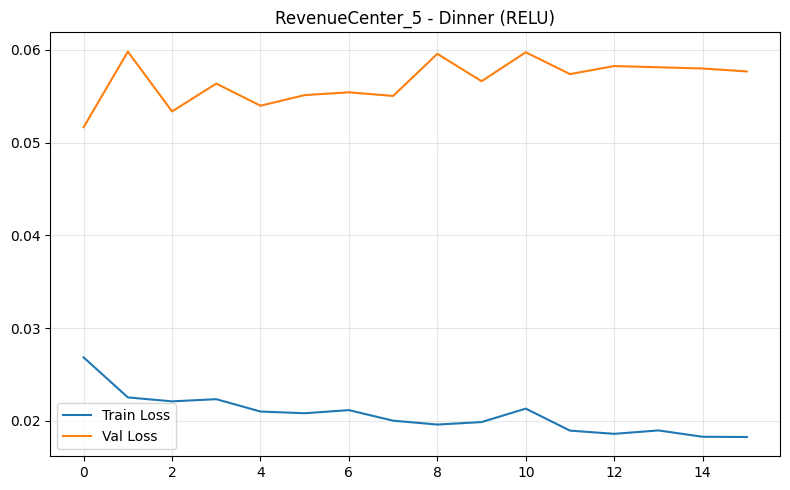

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step


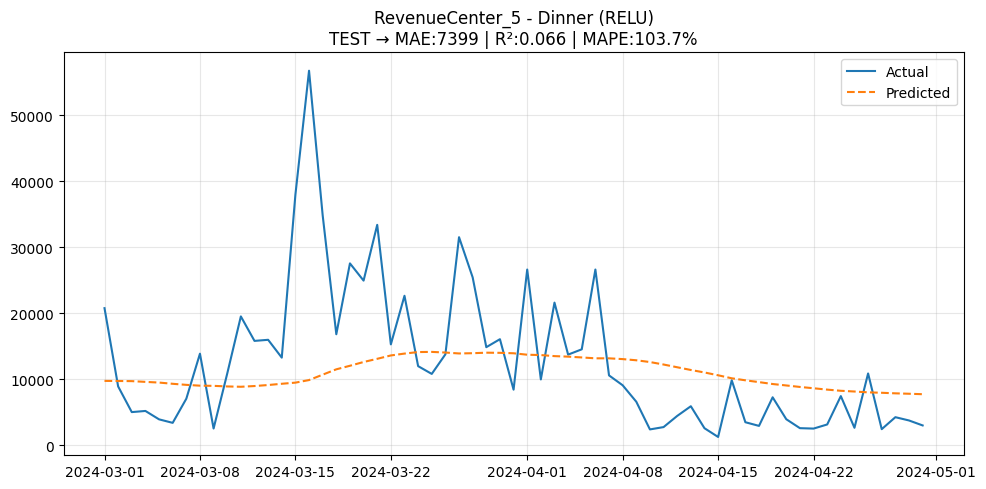

Saved: /content/RevenueCenter_5

Processing: RevenueCenter_7
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 372ms/step - loss: 0.0104 - val_loss: 0.0053
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0091 - val_loss: 0.0046
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0073 - val_loss: 0.0046
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0091 - val_loss: 0.0048
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0087 - val_loss: 0.0046
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0079 - val_loss: 0.0046
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0066 - val_loss: 0.0047
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0100 - val_loss: 0.0046
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0092 - val_loss: 0.0046
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0084 - val_loss: 0.0046
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0075 - val_loss: 0.0046
Epoch 12/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.

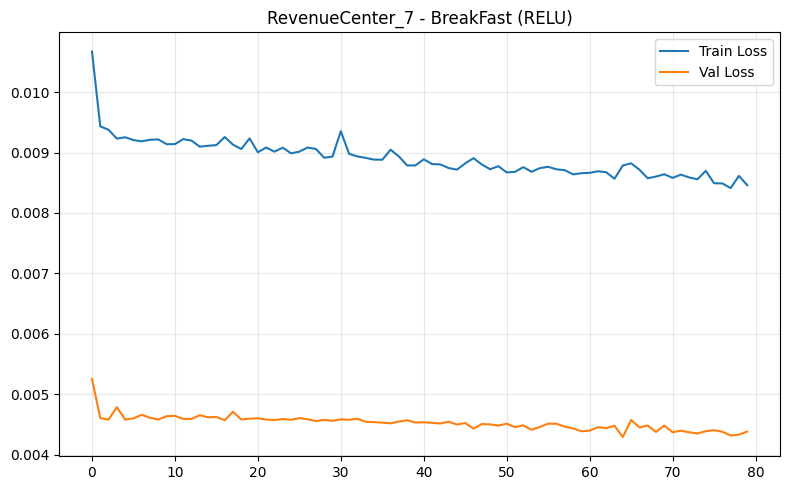

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 588ms/step


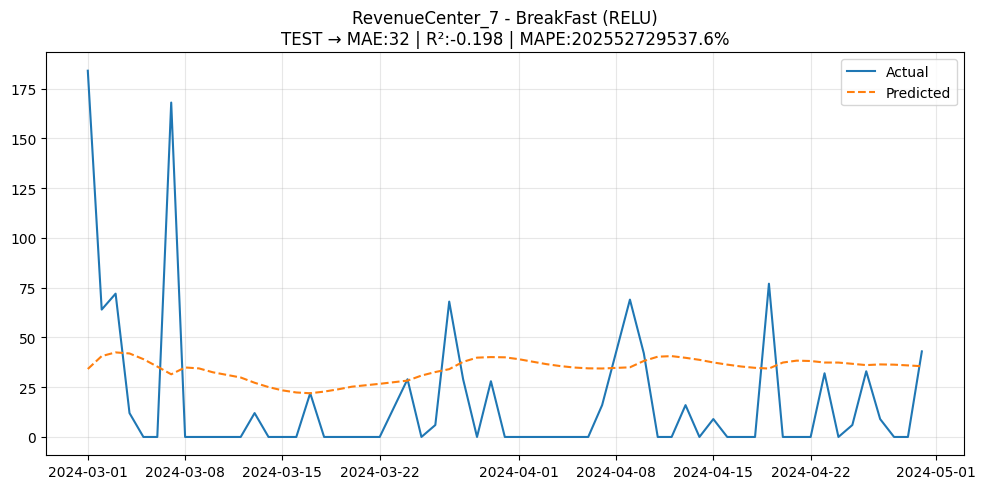

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 328ms/step - loss: 0.0151 - val_loss: 0.0398
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0118 - val_loss: 0.0415
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0115 - val_loss: 0.0411
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0123 - val_loss: 0.0400
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0104 - val_loss: 0.0422
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0100 - val_loss: 0.0402
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0107 - val_loss: 0.0404
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0125 - val_loss: 0.0412
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0100 - val_loss: 0.0415
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0090 - val_loss: 0.0401
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0103 - val_loss: 0.0406
Epoch 12/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.

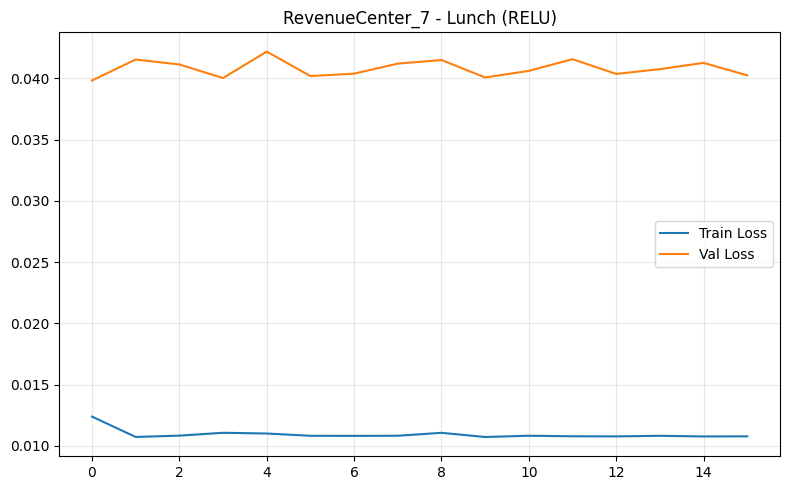

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step


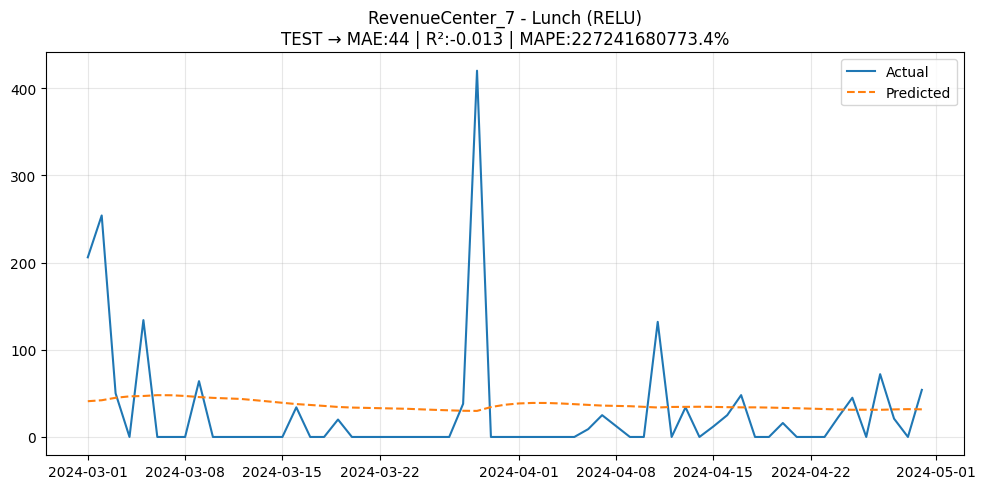

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 279ms/step - loss: 0.0325 - val_loss: 0.1010
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0210 - val_loss: 0.0937
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0164 - val_loss: 0.0985
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0194 - val_loss: 0.0889
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0158 - val_loss: 0.0942
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0185 - val_loss: 0.0900
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0192 - val_loss: 0.0875
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0171 - val_loss: 0.0891
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0181 - val_loss: 0.0844
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0169 - val_loss: 0.0843
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0170 - val_loss: 0.0854
Epoch 12/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.

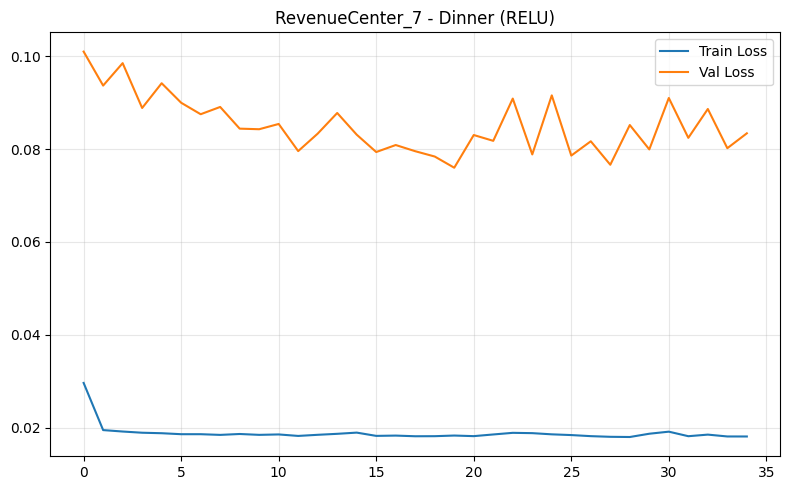

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step


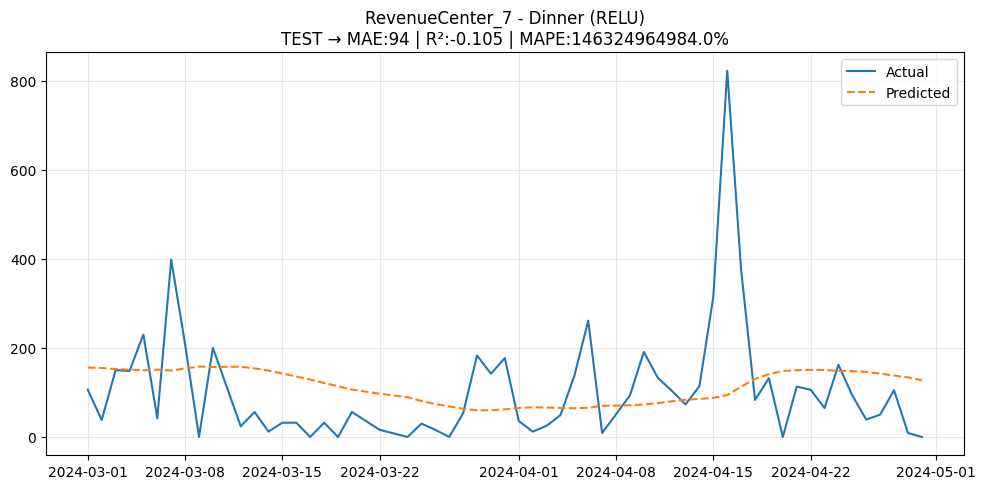

Saved: /content/RevenueCenter_7

Processing: RevenueCenter_2
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 261ms/step - loss: 0.0267 - val_loss: 0.0229
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0159 - val_loss: 0.0313
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0139 - val_loss: 0.0215
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0190 - val_loss: 0.0279
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0166 - val_loss: 0.0274
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0145 - val_loss: 0.0237
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0134 - val_loss: 0.0273
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0156 - val_loss: 0.0232
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0160 - val_loss: 0.0249
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0187 - val_loss: 0.0267
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0162 - val_loss: 0.0247
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.

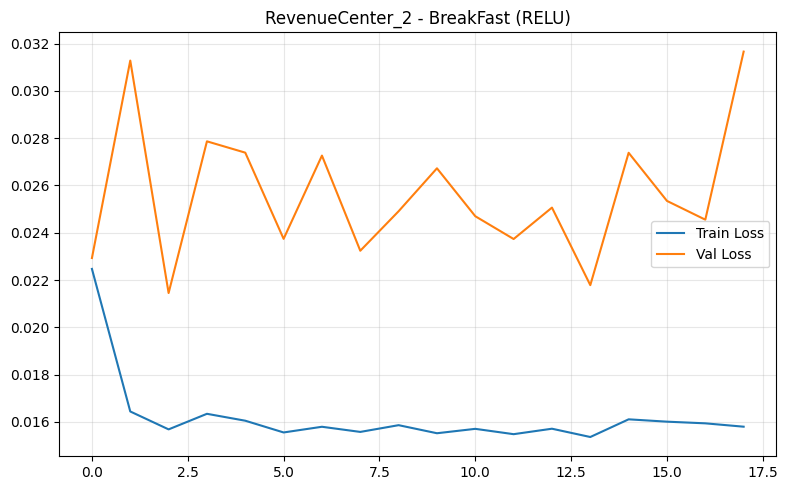

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step


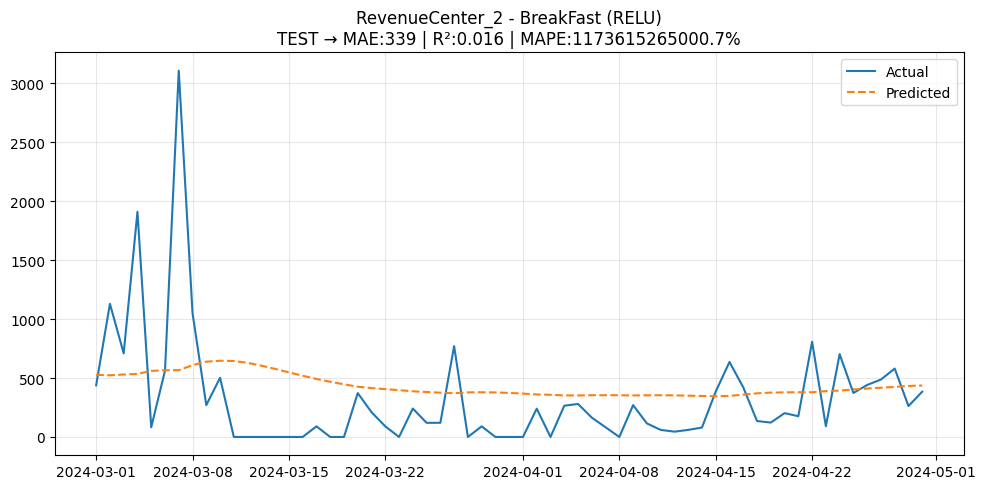

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 424ms/step - loss: 0.0298 - val_loss: 0.0511
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0176 - val_loss: 0.0697
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0153 - val_loss: 0.0625
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0162 - val_loss: 0.0726
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0173 - val_loss: 0.0635
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0170 - val_loss: 0.0654
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0145 - val_loss: 0.0680
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0145 - val_loss: 0.0660
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0126 - val_loss: 0.0628
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0201 - val_loss: 0.0688
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0168 - val_loss: 0.0681
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.

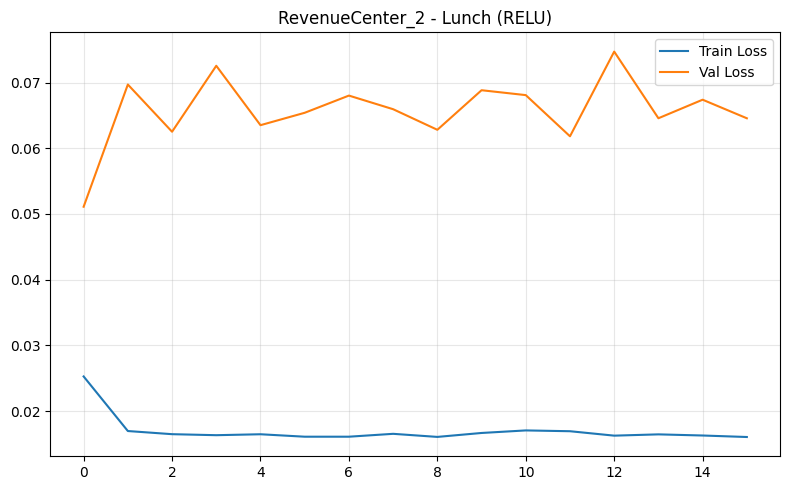

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step


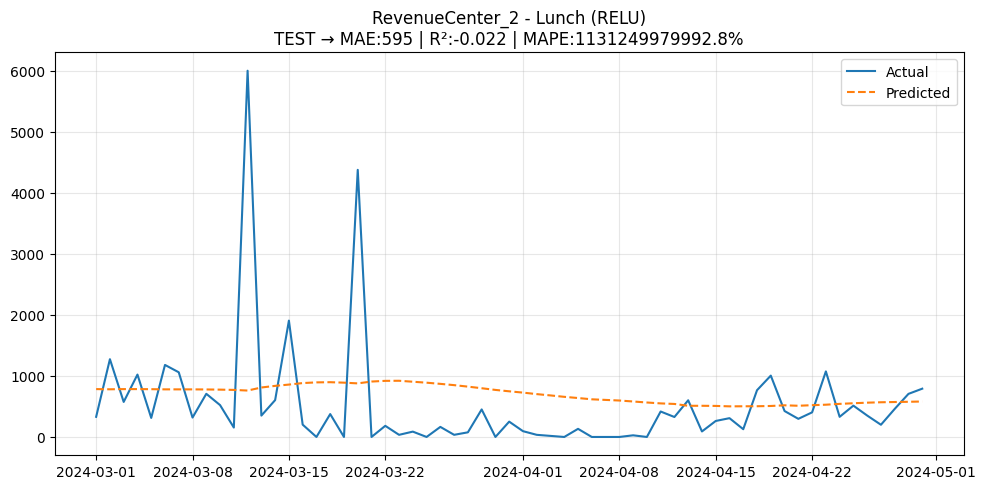

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 304ms/step - loss: 0.0025 - val_loss: 0.0275
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0019 - val_loss: 0.0285
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0020 - val_loss: 0.0292
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0015 - val_loss: 0.0281
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0023 - val_loss: 0.0295
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0025 - val_loss: 0.0286
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0019 - val_loss: 0.0293
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0018 - val_loss: 0.0289
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0019 - val_loss: 0.0293
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0024 - val_loss: 0.0293
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0025 - val_loss: 0.0290
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.

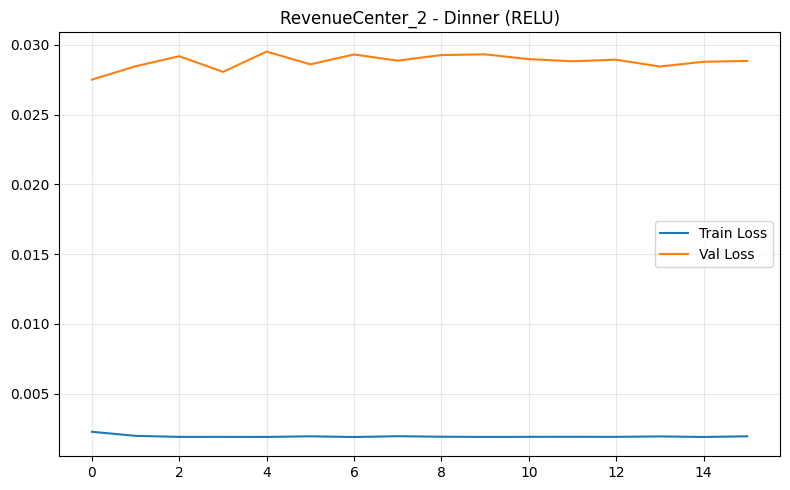

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step


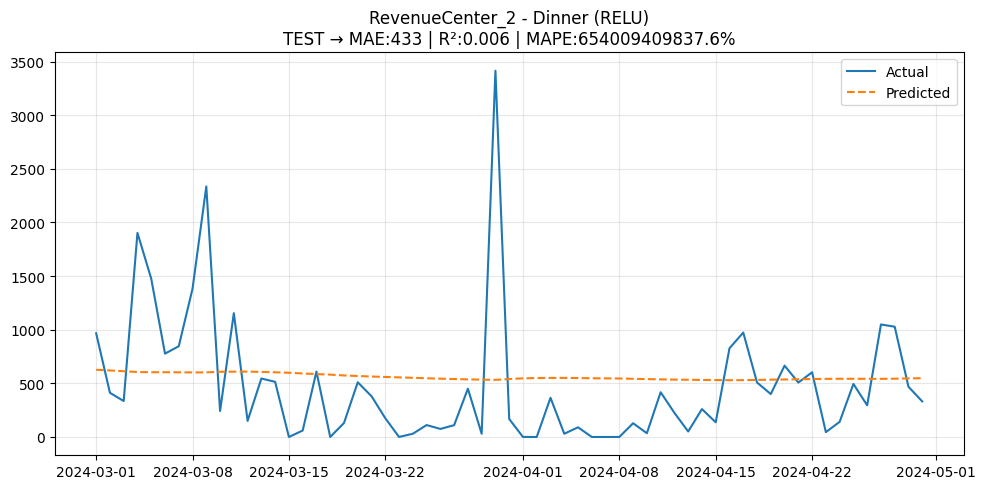

Saved: /content/RevenueCenter_2

Processing: RevenueCenter_1
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 254ms/step - loss: 0.0122 - val_loss: 0.0369
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0054 - val_loss: 0.0518
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0061 - val_loss: 0.0484
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0050 - val_loss: 0.0409
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0053 - val_loss: 0.0395
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0047 - val_loss: 0.0307
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0059 - val_loss: 0.0276
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0044 - val_loss: 0.0362
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0053 - val_loss: 0.0285
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0045 - val_loss: 0.0339
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0054 - val_loss: 0.0377
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.

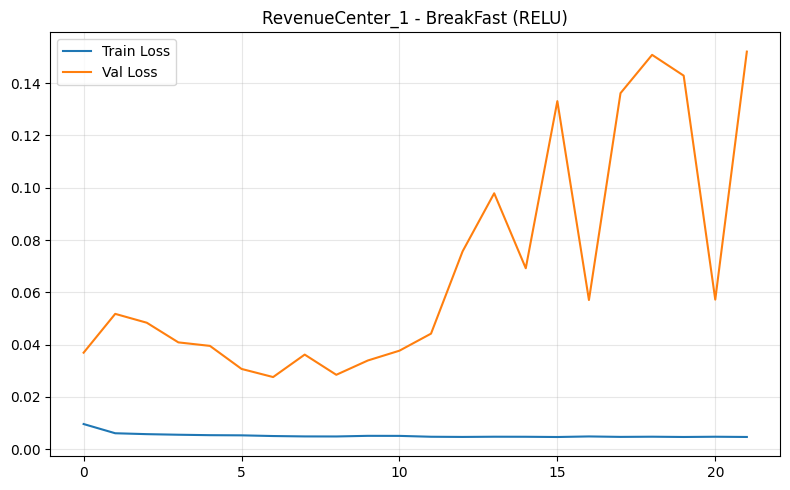

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 636ms/step


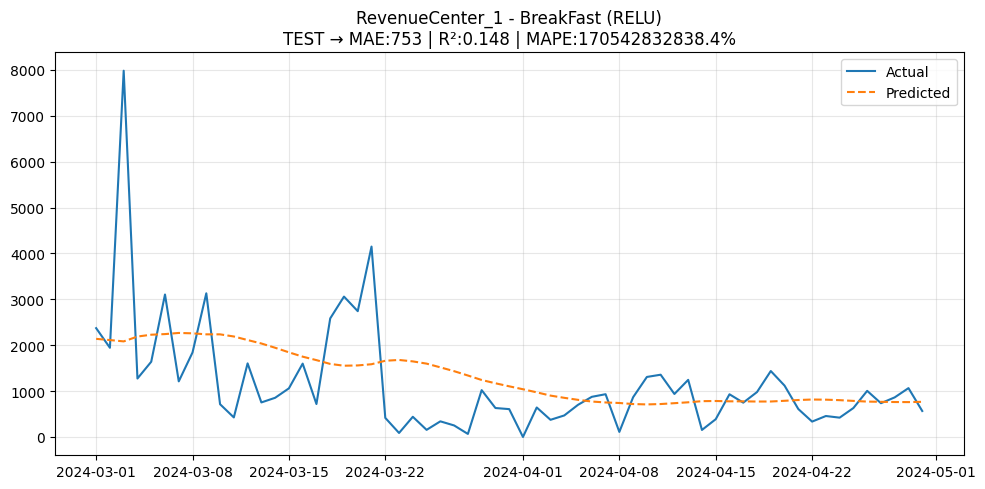

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/step - loss: 0.0227 - val_loss: 0.0618
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0125 - val_loss: 0.0935
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0139 - val_loss: 0.0785
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0115 - val_loss: 0.0791
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0129 - val_loss: 0.0797
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0102 - val_loss: 0.0713
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0107 - val_loss: 0.0711
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0124 - val_loss: 0.0722
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0096 - val_loss: 0.0659
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0106 - val_loss: 0.0684
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0124 - val_loss: 0.0673
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.

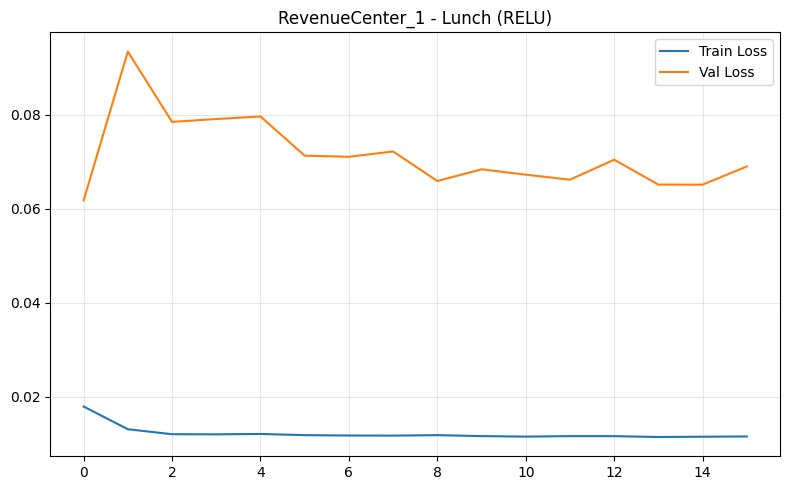

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step


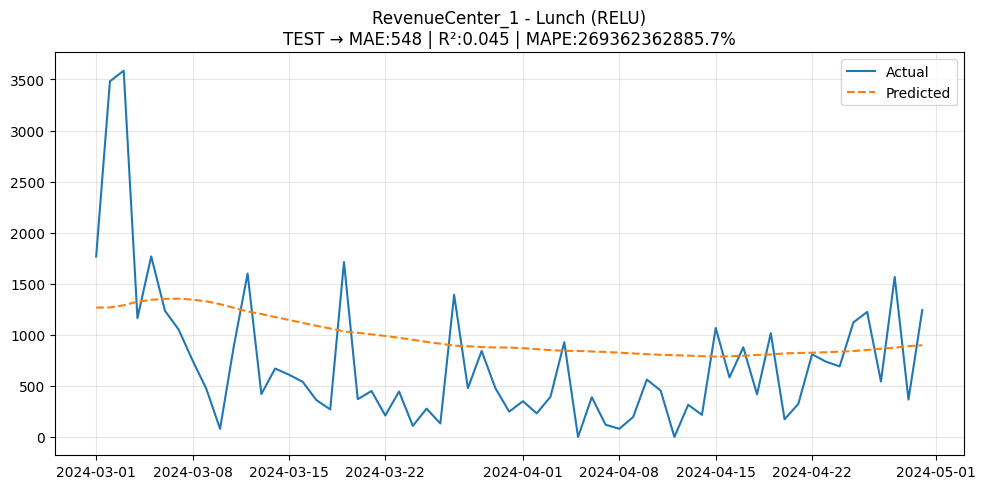

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 252ms/step - loss: 0.0467 - val_loss: 0.0243
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0148 - val_loss: 0.0532
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0166 - val_loss: 0.0330
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0146 - val_loss: 0.0436
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0135 - val_loss: 0.0298
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0135 - val_loss: 0.0354
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0138 - val_loss: 0.0278
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0110 - val_loss: 0.0250
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0161 - val_loss: 0.0406
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0132 - val_loss: 0.0249
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0134 - val_loss: 0.0298
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.

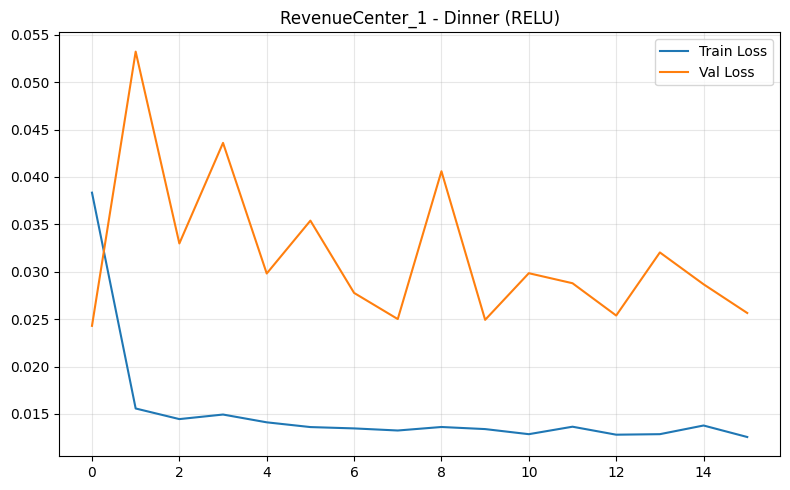

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step


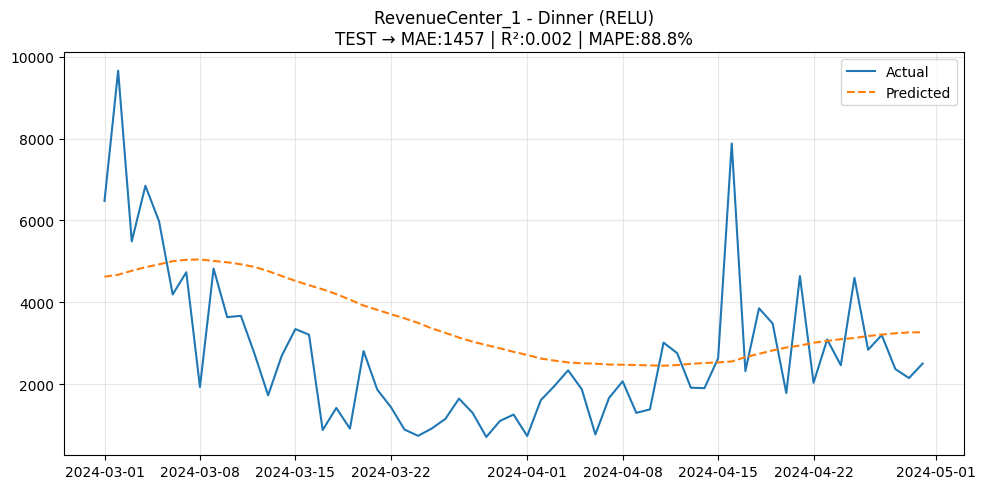

Saved: /content/RevenueCenter_1

Processing: RevenueCenter_6
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 380ms/step - loss: 0.0245 - val_loss: 0.0487
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0293 - val_loss: 0.0513
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0162 - val_loss: 0.0490
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0277 - val_loss: 0.0489
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0281 - val_loss: 0.0493
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0212 - val_loss: 0.0492
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0272 - val_loss: 0.0496
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0190 - val_loss: 0.0498
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0169 - val_loss: 0.0497
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0221 - val_loss: 0.0499
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0207 - val_loss: 0.0495
Epoch 12/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.

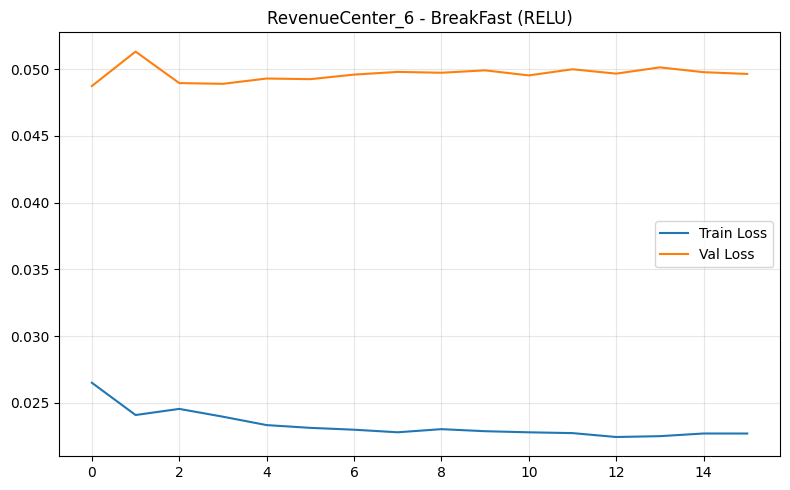

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 578ms/step


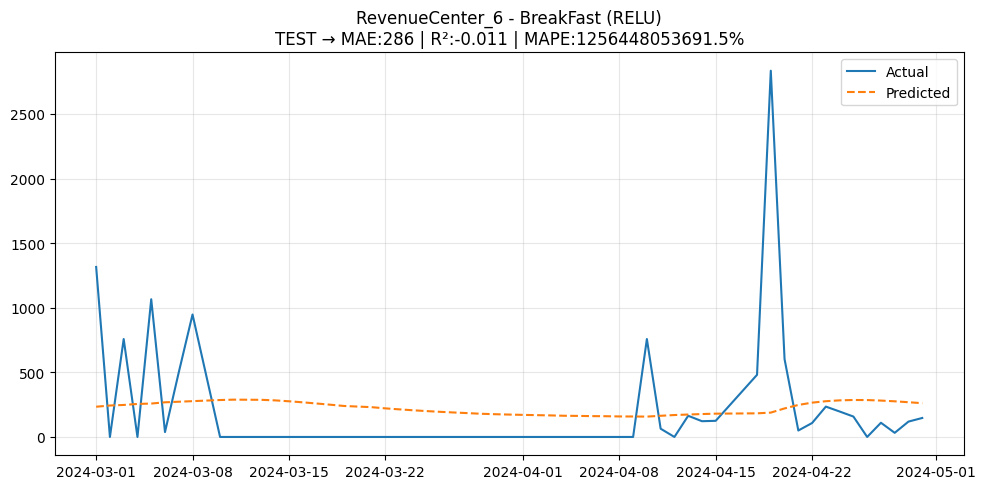

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 292ms/step - loss: 0.0168 - val_loss: 0.0184
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0133 - val_loss: 0.0259
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0097 - val_loss: 0.0213
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0093 - val_loss: 0.0200
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0139 - val_loss: 0.0180
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0115 - val_loss: 0.0186
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0126 - val_loss: 0.0186
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0135 - val_loss: 0.0187
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0097 - val_loss: 0.0185
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0096 - val_loss: 0.0189
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0121 - val_loss: 0.0193
Epoch 12/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.

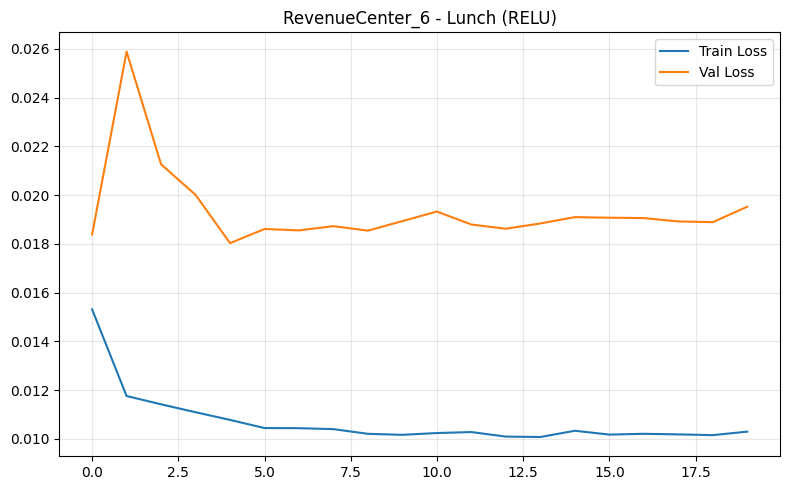

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step


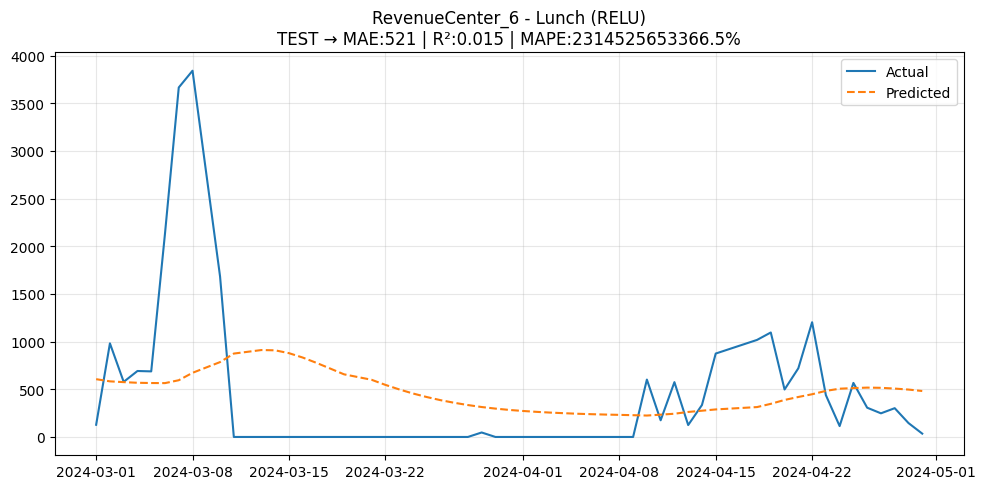

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 287ms/step - loss: 0.0016 - val_loss: 0.0245
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0022 - val_loss: 0.0250
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0041 - val_loss: 0.0248
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0019 - val_loss: 0.0249
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0041 - val_loss: 0.0248
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0032 - val_loss: 0.0250
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0063 - val_loss: 0.0248
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0023 - val_loss: 0.0248
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0032 - val_loss: 0.0248
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0023 - val_loss: 0.0248
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0019 - val_loss: 0.0248
Epoch 12/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.

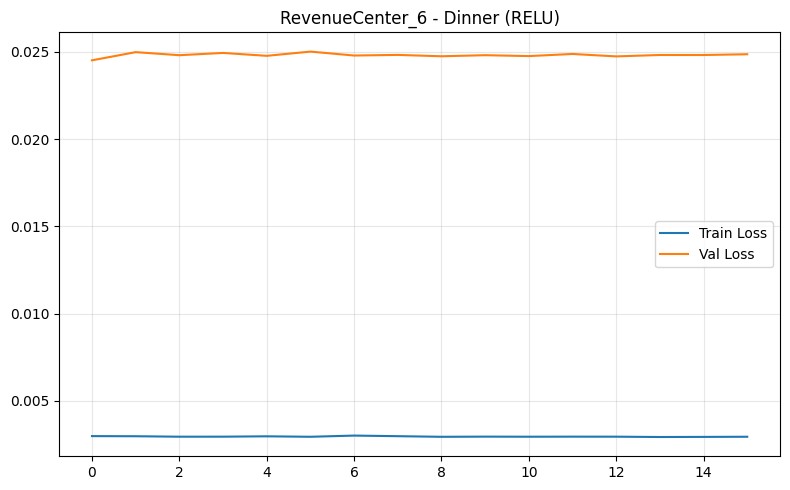

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step


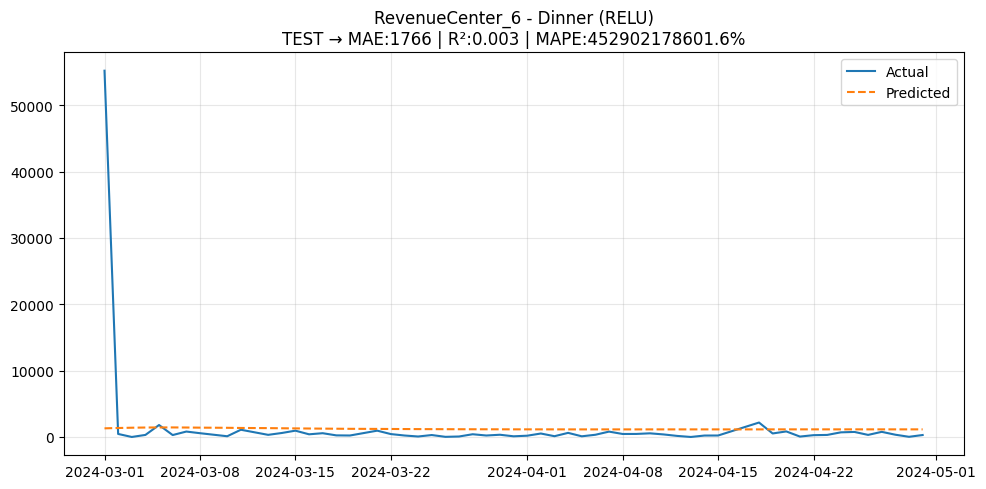

Saved: /content/RevenueCenter_6

Processing: RevenueCenter_4
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 317ms/step - loss: 0.0033 - val_loss: 1.3315e-07
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 4.7952e-04 - val_loss: 5.5672e-06
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0081 - val_loss: 2.1415e-05
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 7.5323e-04 - val_loss: 1.7352e-06
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 4.8402e-04 - val_loss: 1.2589e-06
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 7.4574e-04 - val_loss: 2.3322e-05
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0033 - val_loss: 1.8581e-05
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 7.5149e-04 - val_loss: 2.1285e-07
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0027 - val_loss: 4.2142e-05
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0080 - val_loss: 3.3988e-06
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0055 - val_loss: 7.6777e-07

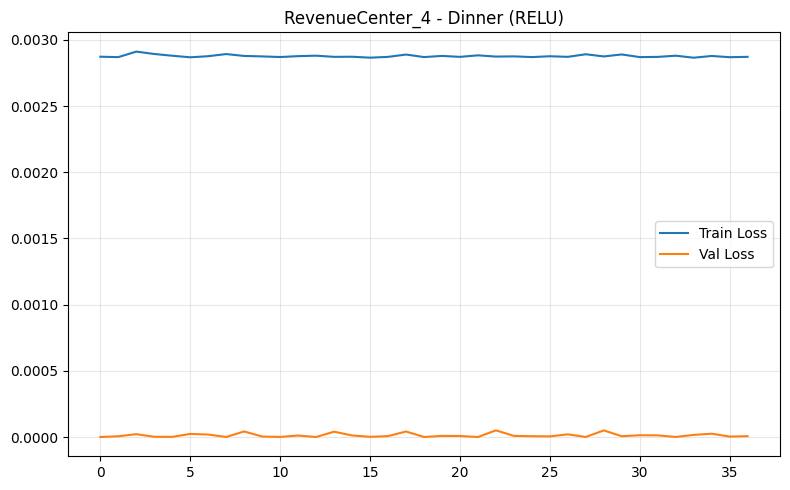

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step


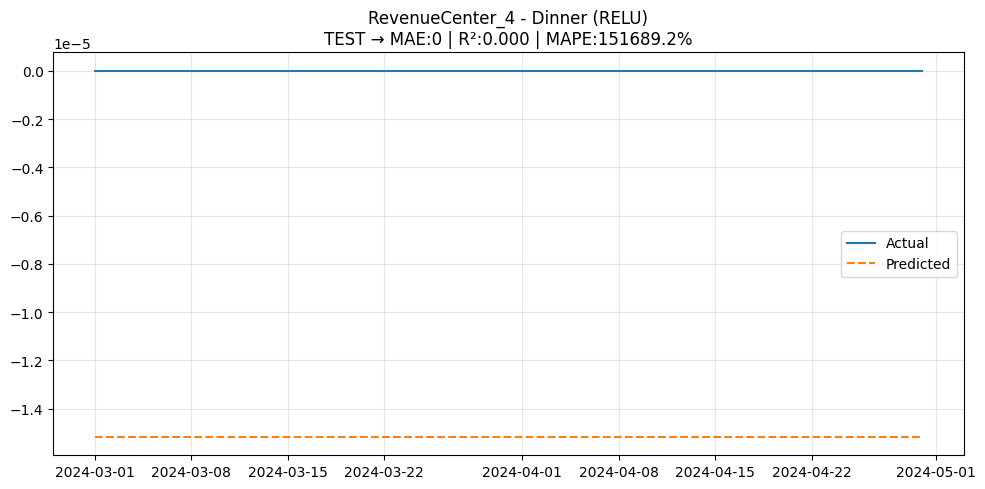

Saved: /content/RevenueCenter_4

Processing: RevenueCenter_8
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 357ms/step - loss: 0.0111 - val_loss: 0.0025
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0070 - val_loss: 0.0024
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0094 - val_loss: 0.0024
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0085 - val_loss: 0.0023
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0091 - val_loss: 0.0024
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0077 - val_loss: 0.0023
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0069 - val_loss: 0.0024
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0058 - val_loss: 0.0025
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0080 - val_loss: 0.0025
Epoch 10/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0090 - val_loss: 0.0023
Epoch 11/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0074 - val_loss: 0.0025
Epoch 12/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.

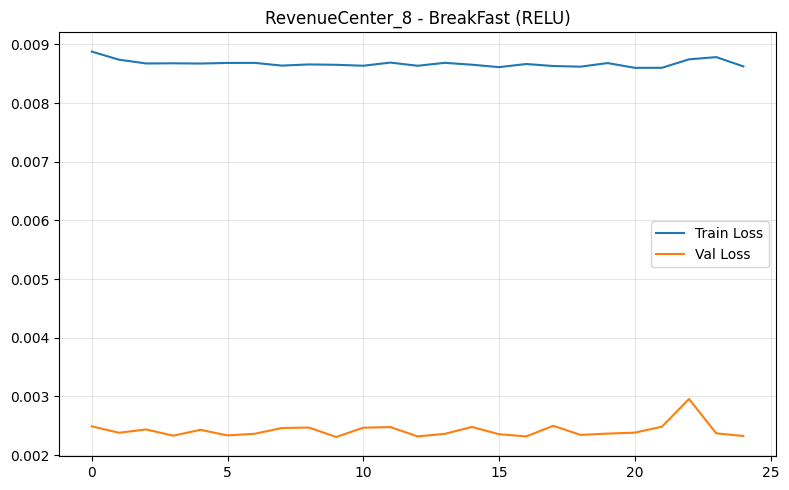

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step


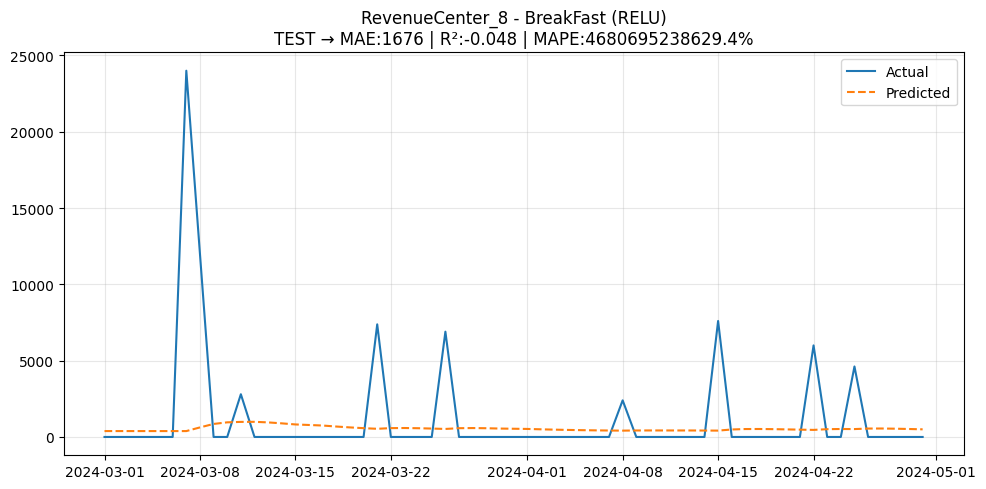

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 314ms/step - loss: 0.0224 - val_loss: 0.1070
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0129 - val_loss: 0.1029
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0160 - val_loss: 0.1087
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0161 - val_loss: 0.1047
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0133 - val_loss: 0.1059
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0205 - val_loss: 0.1064
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0145 - val_loss: 0.1063
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0166 - val_loss: 0.1021
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0139 - val_loss: 0.1069
Epoch 10/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0147 - val_loss: 0.1012
Epoch 11/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0169 - val_loss: 0.1066
Epoch 12/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.

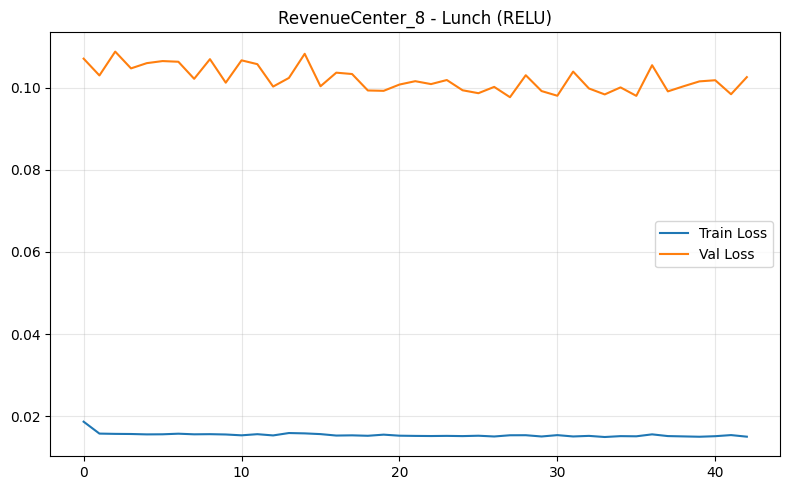

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step


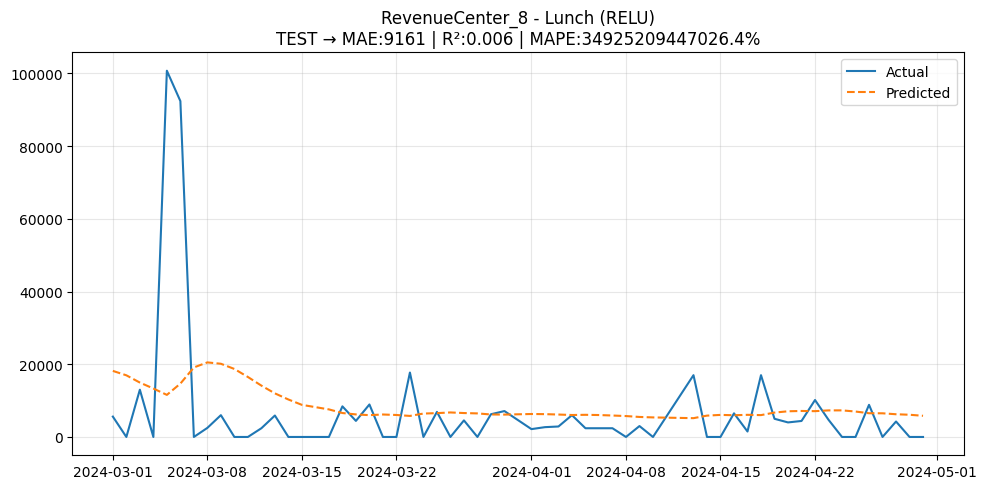

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 312ms/step - loss: 0.0217 - val_loss: 0.0619
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0122 - val_loss: 0.0551
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0148 - val_loss: 0.0589
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0136 - val_loss: 0.0545
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0129 - val_loss: 0.0584
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0112 - val_loss: 0.0585
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0122 - val_loss: 0.0547
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0168 - val_loss: 0.0588
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0130 - val_loss: 0.0572
Epoch 10/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0114 - val_loss: 0.0567
Epoch 11/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0161 - val_loss: 0.0542
Epoch 12/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.

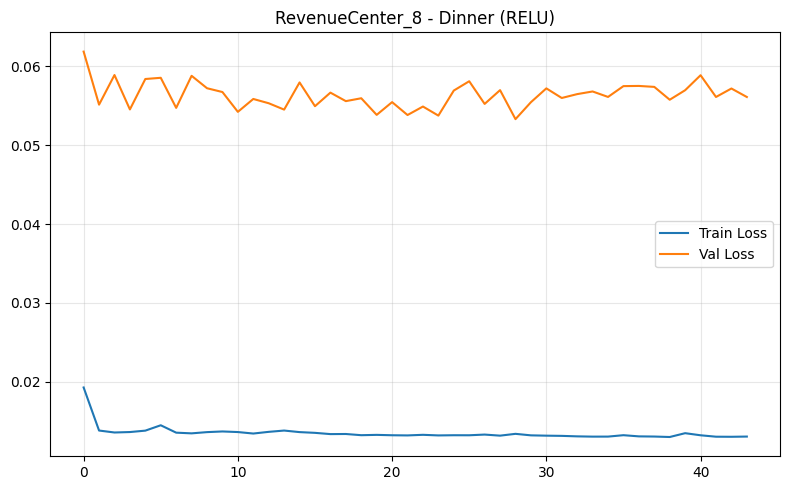

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step


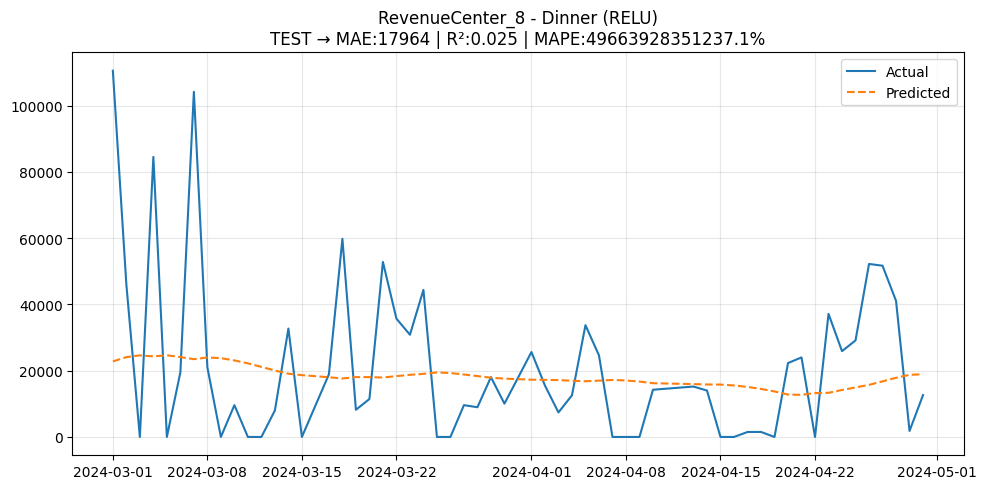

Saved: /content/RevenueCenter_8

Processing: RevenueCenter_3
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 306ms/step - loss: 0.0346 - val_loss: 0.0380
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0260 - val_loss: 0.0445
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0247 - val_loss: 0.0396
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0249 - val_loss: 0.0372
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0250 - val_loss: 0.0397
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0213 - val_loss: 0.0377
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0210 - val_loss: 0.0375
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0209 - val_loss: 0.0386
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0215 - val_loss: 0.0376
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0221 - val_loss: 0.0376
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0217 - val_loss: 0.0373
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.

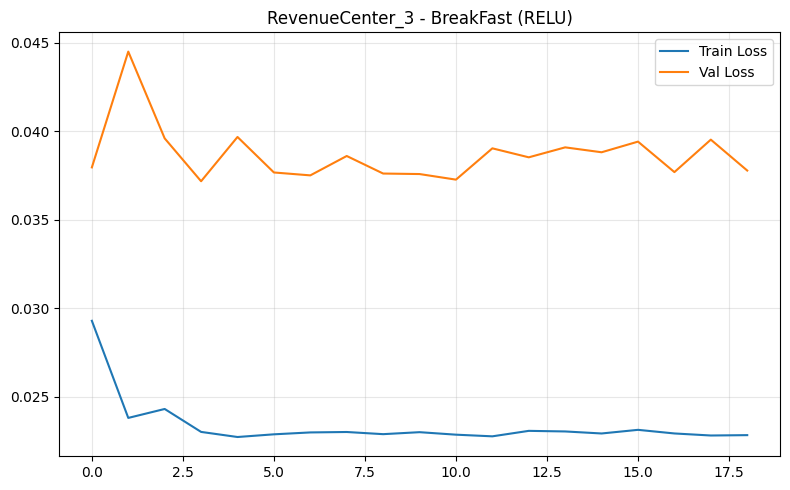

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step


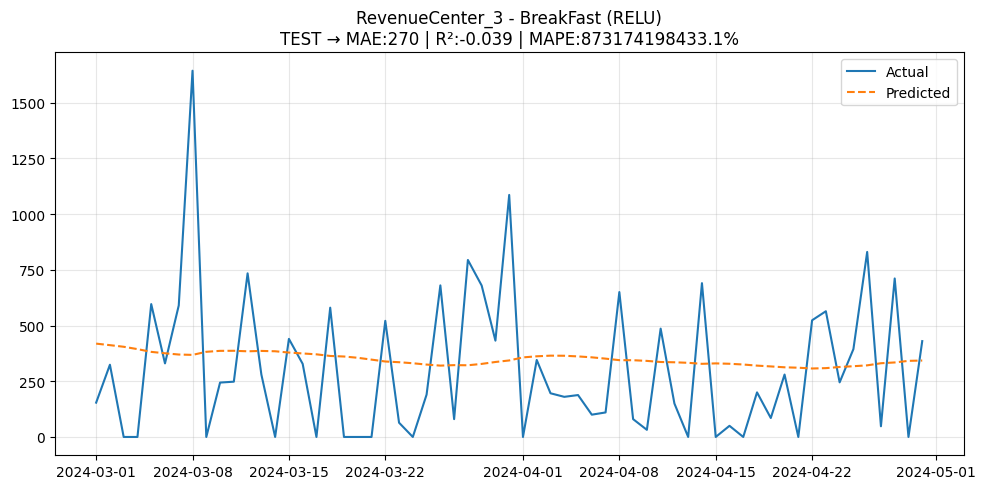

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 255ms/step - loss: 0.0272 - val_loss: 0.0495
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0102 - val_loss: 0.0587
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0098 - val_loss: 0.0562
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0095 - val_loss: 0.0583
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0085 - val_loss: 0.0586
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0104 - val_loss: 0.0577
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0094 - val_loss: 0.0589
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0099 - val_loss: 0.0597
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0090 - val_loss: 0.0569
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0096 - val_loss: 0.0567
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0096 - val_loss: 0.0588
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.

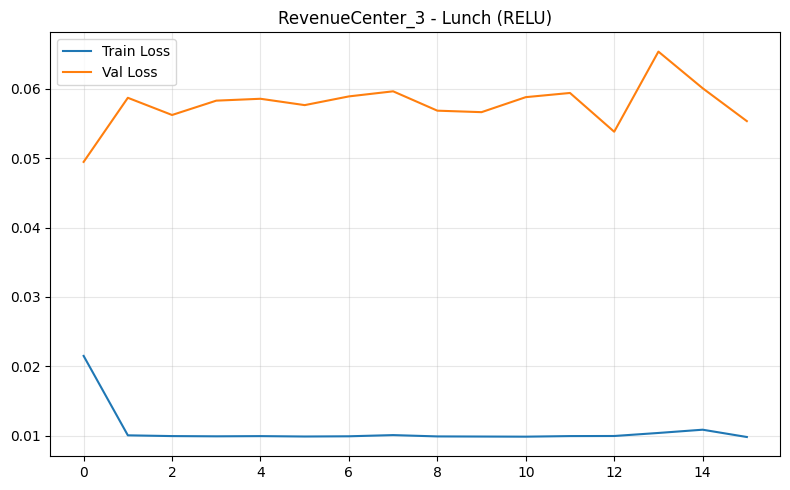

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step


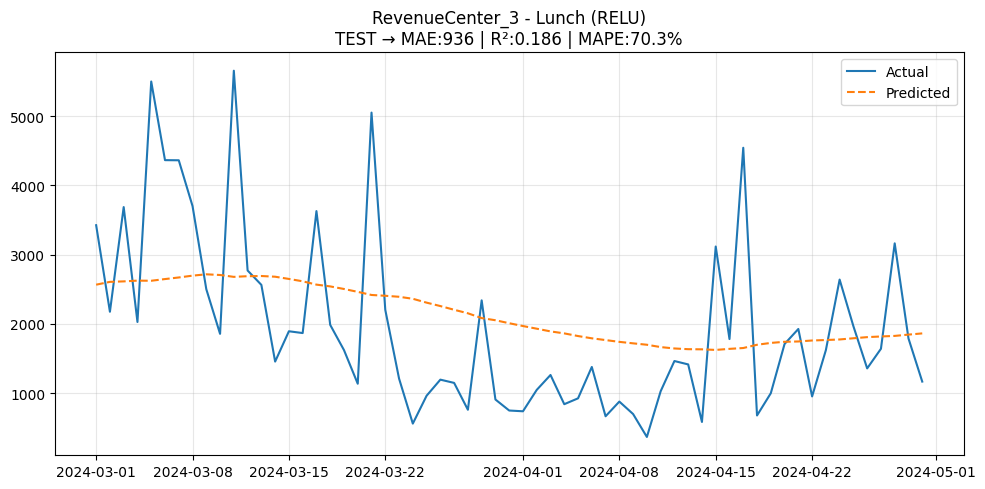

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 258ms/step - loss: 0.0612 - val_loss: 0.0627
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0137 - val_loss: 0.1147
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0122 - val_loss: 0.0621
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0136 - val_loss: 0.1159
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0128 - val_loss: 0.0468
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0124 - val_loss: 0.0765
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0132 - val_loss: 0.0547
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0113 - val_loss: 0.0451
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0109 - val_loss: 0.0387
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0099 - val_loss: 0.0288
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0107 - val_loss: 0.0272
Epoch 12/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.

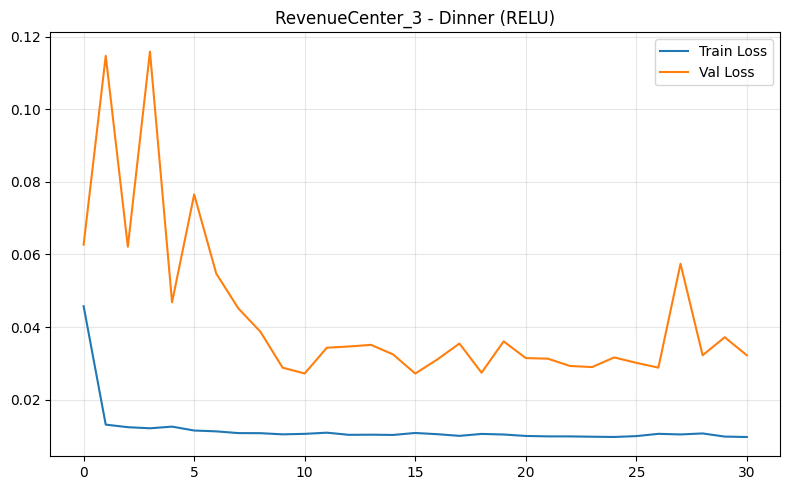

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step


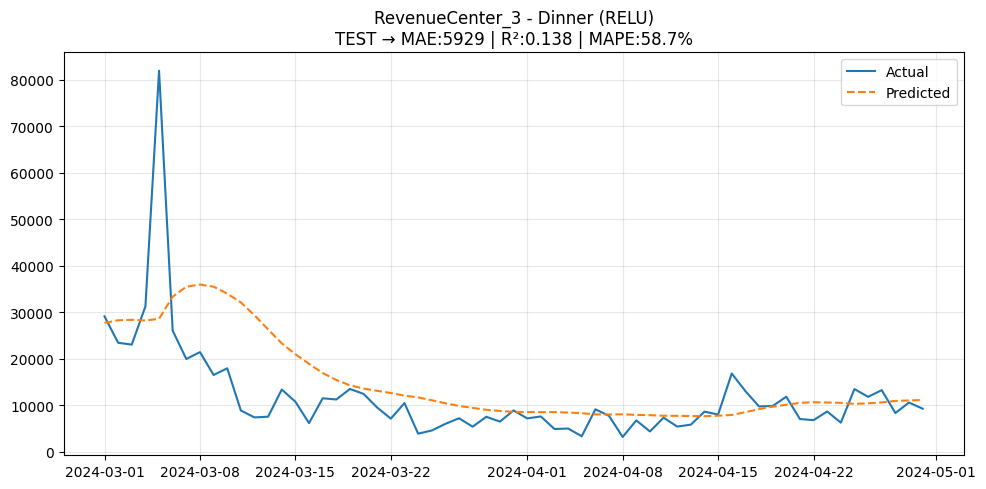

Saved: /content/RevenueCenter_3

Processing: RevenueCenter_9
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 410ms/step - loss: 0.0103 - val_loss: 0.0759
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0102 - val_loss: 0.0929
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0072 - val_loss: 0.0924
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0091 - val_loss: 0.0788
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0090 - val_loss: 0.0875
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0098 - val_loss: 0.0780
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0081 - val_loss: 0.0717
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0105 - val_loss: 0.0713
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0090 - val_loss: 0.0668
Epoch 10/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0079 - val_loss: 0.0575
Epoch 11/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0078 - val_loss: 0.0611
Epoch 12/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.

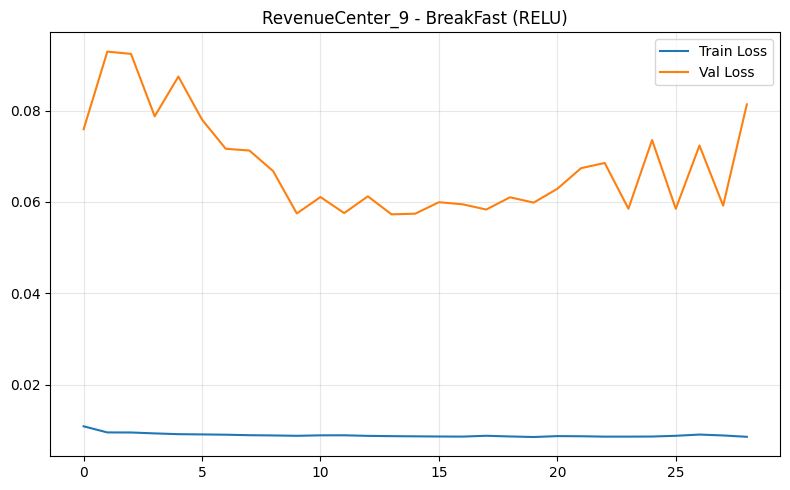

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step


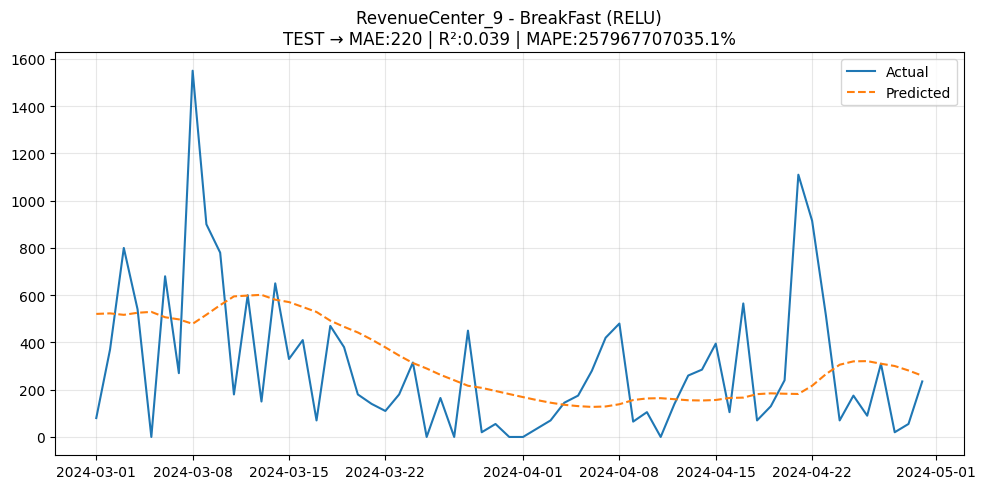

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 321ms/step - loss: 0.0716 - val_loss: 0.0565
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0388 - val_loss: 0.0467
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0329 - val_loss: 0.0494
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0339 - val_loss: 0.0458
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0336 - val_loss: 0.0470
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0316 - val_loss: 0.0471
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0297 - val_loss: 0.0468
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0261 - val_loss: 0.0466
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0317 - val_loss: 0.0467
Epoch 10/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0284 - val_loss: 0.0471
Epoch 11/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0354 - val_loss: 0.0482
Epoch 12/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.

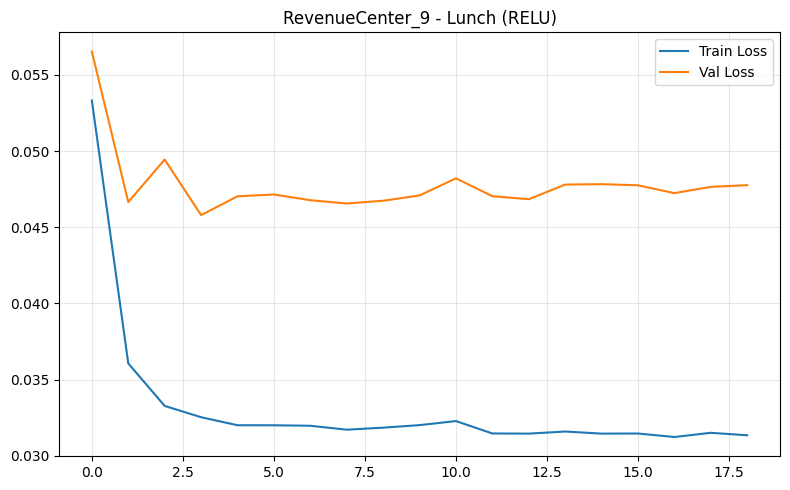

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step


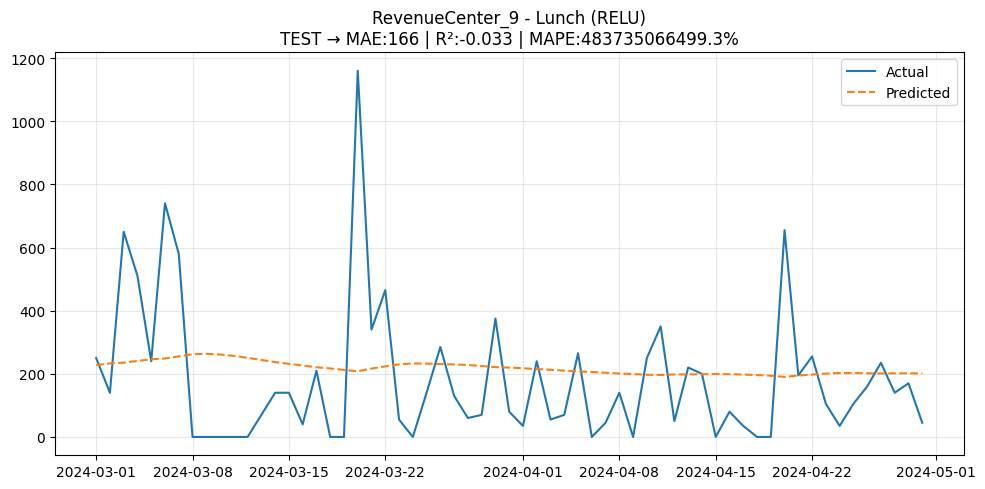

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 317ms/step - loss: 0.0223 - val_loss: 0.0155
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0203 - val_loss: 0.0133
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0224 - val_loss: 0.0141
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0240 - val_loss: 0.0136
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0215 - val_loss: 0.0140
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0232 - val_loss: 0.0137
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0234 - val_loss: 0.0140
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0203 - val_loss: 0.0137
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0201 - val_loss: 0.0142
Epoch 10/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0266 - val_loss: 0.0137
Epoch 11/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0230 - val_loss: 0.0141
Epoch 12/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.

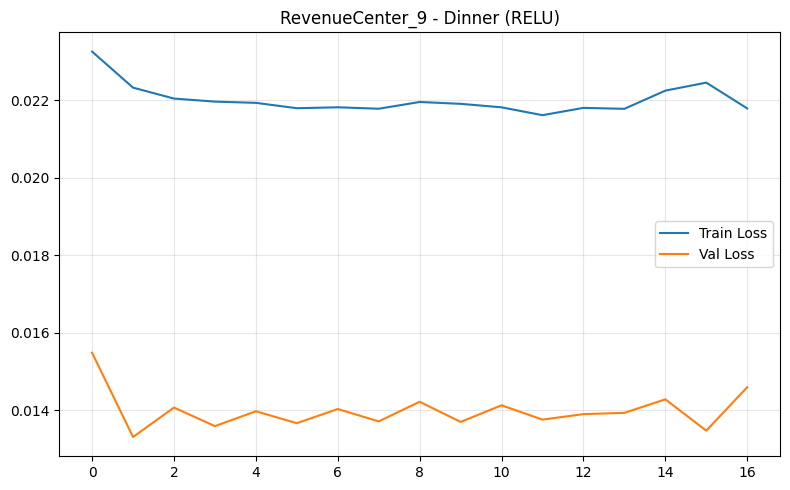

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step


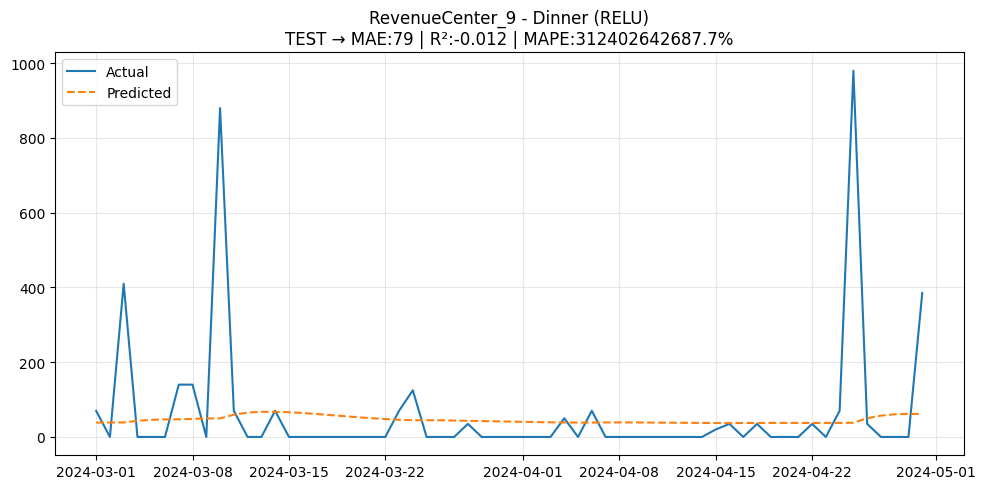

Saved: /content/RevenueCenter_9

ALL CENTERS COMPLETED — RELU MODEL


In [7]:
for file in files:

    center_name = os.path.basename(file).replace(".xlsx", "")
    print("\nProcessing:", center_name)

    center_path = os.path.join(output_folder, center_name)
    os.makedirs(center_path, exist_ok=True)

    df = pd.read_excel(file)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    split_date = df["Date"].max() - pd.DateOffset(months=2)
    meals = ["BreakFast", "Lunch", "Dinner"]

    for meal in meals:

        temp_df = df[["Date", meal]].copy()
        temp_df.rename(columns={meal: "y"}, inplace=True)

        train_df = temp_df[temp_df["Date"] <= split_date]
        test_df  = temp_df[temp_df["Date"] > split_date]

        if train_df["y"].nunique() <= 1:
            continue

        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_df[["y"]])
        test_scaled  = scaler.transform(test_df[["y"]])

        WINDOW = 30
        X_train, y_train = create_sequences(train_scaled, WINDOW)
        combined = np.vstack([train_scaled[-WINDOW:], test_scaled])
        X_test, y_test = create_sequences(combined, WINDOW)

        X_train = X_train.reshape(-1, WINDOW, 1)
        X_test  = X_test.reshape(-1, WINDOW, 1)

        # =========================
        # MODEL — RELU
        # =========================
        model = Sequential([

            # 1st LSTM layer
            LSTM(
                128,
                activation="relu",
                return_sequences=True,
                input_shape=(WINDOW, 1)
            ),

            # 2nd LSTM layer
            LSTM(
                64,
                activation="relu",
                return_sequences=False
            ),

            # Hidden Dense layer
            Dense(32, activation="relu"),

            # Output layer
            Dense(1)
        ])

        model.compile(optimizer="adam", loss="mse")

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            epochs=300,
            batch_size=32,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=1
        )

        # =========================
        # LOSS PLOT
        # =========================
        plt.figure(figsize=(8,5))
        plt.plot(history.history["loss"], label="Train Loss")
        plt.plot(history.history["val_loss"], label="Val Loss")
        plt.title(f"{center_name} - {meal} (RELU)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_loss_relu.png"), dpi=300)
        plt.show()
        plt.close()

        # =========================
        # PREDICTIONS
        # =========================
        y_train_pred = scaler.inverse_transform(model.predict(X_train))
        y_test_pred  = scaler.inverse_transform(model.predict(X_test))
        y_train_true = scaler.inverse_transform(y_train.reshape(-1,1))
        y_test_true  = scaler.inverse_transform(y_test.reshape(-1,1))

        train_mae  = mean_absolute_error(y_train_true, y_train_pred)
        train_r2   = r2_score(y_train_true, y_train_pred)
        train_mape = mape(y_train_true, y_train_pred)

        test_mae  = mean_absolute_error(y_test_true, y_test_pred)
        test_r2   = r2_score(y_test_true, y_test_pred)
        test_mape = mape(y_test_true, y_test_pred)

        plt.figure(figsize=(10,5))
        plt.plot(test_df["Date"], y_test_true, label="Actual")
        plt.plot(test_df["Date"], y_test_pred, "--", label="Predicted")
        plt.title(
            f"{center_name} - {meal} (RELU)\n"
            f"TEST → MAE:{test_mae:.0f} | R²:{test_r2:.3f} | MAPE:{test_mape:.1f}%"
        )
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_pred_tanh.png"), dpi=300)
        plt.show()
        plt.close()

    print("Saved:", center_path)

print("\nALL CENTERS COMPLETED — RELU MODEL")